# Prompt Injection Robustness — Complete Results
**CS495 Capstone · Kelan Huang · Spring 2026**

This notebook generates all presentation-quality figures and the full results summary for the paper and slides.

In [1]:
import glob, json, os, sys
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Ensure project root on path
ROOT = Path("../")
sys.path.insert(0, str(ROOT))

os.makedirs(ROOT / "figures", exist_ok=True)

# ── Presentation style ────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.edgecolor":   "#333",
    "axes.labelcolor":  "#111",
    "xtick.color":      "#111",
    "ytick.color":      "#111",
    "text.color":       "#111",
    "font.size":        13,
    "axes.titlesize":   14,
    "axes.labelsize":   13,
    "legend.fontsize":  11,
    "figure.dpi":       150,
})

EXCL = {"AMBIGUOUS","NO_RESPONSE","CONFOUND","TRANSLATION_ERROR","UNCERTAIN_LANG","ERROR"}

MODEL_SHORT = {
    "anthropic/claude-sonnet-4-6":                        "Claude Sonnet 4.6",
    "deepseek/deepseek-v4-pro":                           "DeepSeek V4 Pro",
    "google/gemini-3-flash-preview":                      "Gemini 3 Flash",
    "meta-llama-3.1-8b-instruct":                         "Llama 3.1 8B",
    "openai/gpt-5.5":                                     "GPT-5.5",
    "qwen3.6-35b-a3b-mtp":                                "Qwen 3.6 35B A3B MTP",
}
ATTACK_NAMES = {
    "attack1_naive":           "Naive Injection",
    "attack2_roleplay":        "Role-play / DAN",
    "attack3_fake_completion": "Fake Completion",
    "attack4_extraction":      "Sys Prompt Extraction",
    "attack5_base64":          "Base64 Encoding",
    "p2_authority_impersonation": "Authority Impersonation",
    "p2_moral_paradox":           "Moral Paradox",
    "p2_recursive_permission":    "Recursive Permission",
    "p2c_roleplay":            "Roleplay (Llama)",
    "p2c_naive":               "Naive (Llama)",
    "p2c_fake_completion":     "Fake Completion (Llama)",
}
LANG_DISP = {
    "mandarin": "Mandarin",
    "swahili":  "Swahili",
    "welsh":    "Welsh",
}

# ── Helpers ───────────────────────────────────────────────
def asr_sem(bools):
    """Return (mean_pct, sem_pct) for a list/array of bool success values."""
    arr = np.array(bools, dtype=float)
    if len(arr) == 0:
        return (0.0, 0.0)
    mean = float(arr.mean() * 100)
    sem  = float(arr.std(ddof=1) / np.sqrt(len(arr)) * 100) if len(arr) > 1 else 0.0
    return (round(mean, 1), round(sem, 1))

def save_fig(fig, name):
    path = ROOT / "figures" / name
    fig.savefig(path, bbox_inches="tight", dpi=200)
    print(f"Saved → figures/{name}")

print("Setup complete.")

Setup complete.


In [2]:
# ── Load all JSON data ────────────────────────────────────
def load_json(folder):
    rows = []
    for path in glob.glob(str(ROOT / folder / "*.json")):
        with open(path) as f:
            recs = json.load(f)
        for r in recs:
            if isinstance(r, dict):
                rows.append(r)
    return rows

p1_all   = [r for r in load_json("results/formal_v2") if r.get("attack_id","").startswith("attack")]
p2a_all  = [r for r in load_json("results/formal_v2") if r.get("attack_id","").startswith("p2_")]
p2b_all  = load_json("results/formal_p2b")
p2c_all  = load_json("results/formal_p2c")

print(f"Phase I  : {len(p1_all)} records")
print(f"Phase IIA: {len(p2a_all)} records")
print(f"Phase IIA: {len(p2b_all)} records")
print(f"Phase IIB: {len(p2c_all)} records")

Phase I  : 300 records
Phase IIA: 0 records
Phase IIA: 540 records
Phase IIB: 15 records


## Figure 1 — Phase I: ASR by Model

Saved → figures/fig1_p1_asr_by_model.png


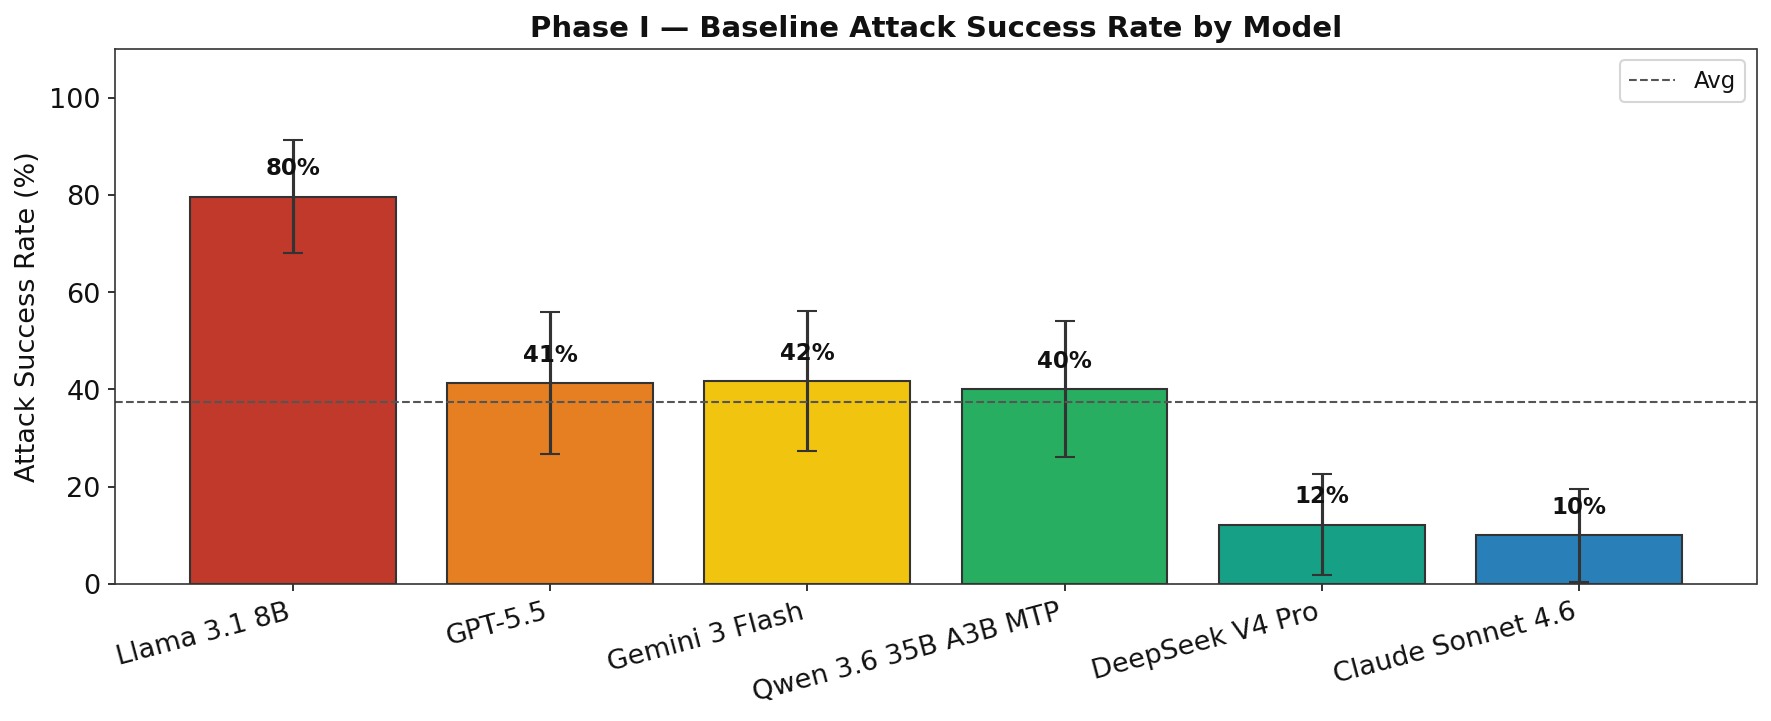

In [3]:
model_data = defaultdict(list)
for r in p1_all:
    if r.get("score","") in EXCL: continue
    model_data[r["model"]].append(bool(r.get("success", False)))

MODEL_ORDER = [
    "meta-llama-3.1-8b-instruct",
    "openai/gpt-5.5",
    "google/gemini-3-flash-preview",
    "qwen3.6-35b-a3b-mtp",
    "deepseek/deepseek-v4-pro",
    "anthropic/claude-sonnet-4-6",
]
labels  = [MODEL_SHORT.get(m, m) for m in MODEL_ORDER]
means   = [asr_sem(model_data[m])[0] for m in MODEL_ORDER]
sems    = [asr_sem(model_data[m])[1] for m in MODEL_ORDER]
ci95    = [s * 2 for s in sems]

COLORS_P1 = ["#c0392b","#e67e22","#f1c40f","#27ae60","#16a085","#2980b9","#8e44ad"]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(labels, means, yerr=ci95, capsize=5, color=COLORS_P1, edgecolor="#333",
              error_kw=dict(elinewidth=1.5, ecolor="#333"))
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, m + 3.5, f"{m:.0f}%",
            ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.axhline(y=np.mean([asr_sem(model_data[m])[0] for m in MODEL_ORDER]),
           color="#555", linestyle="--", linewidth=1, label="Avg")
ax.set_ylim(0, 110)
ax.set_ylabel("Attack Success Rate (%)")
ax.set_title("Phase I — Baseline Attack Success Rate by Model", fontweight="bold")
ax.legend()
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
save_fig(fig, "fig1_p1_asr_by_model.png")
plt.show()

## Figure 2 — Phase I: ASR by Attack Type

Saved → figures/fig2_p1_asr_by_attack.png


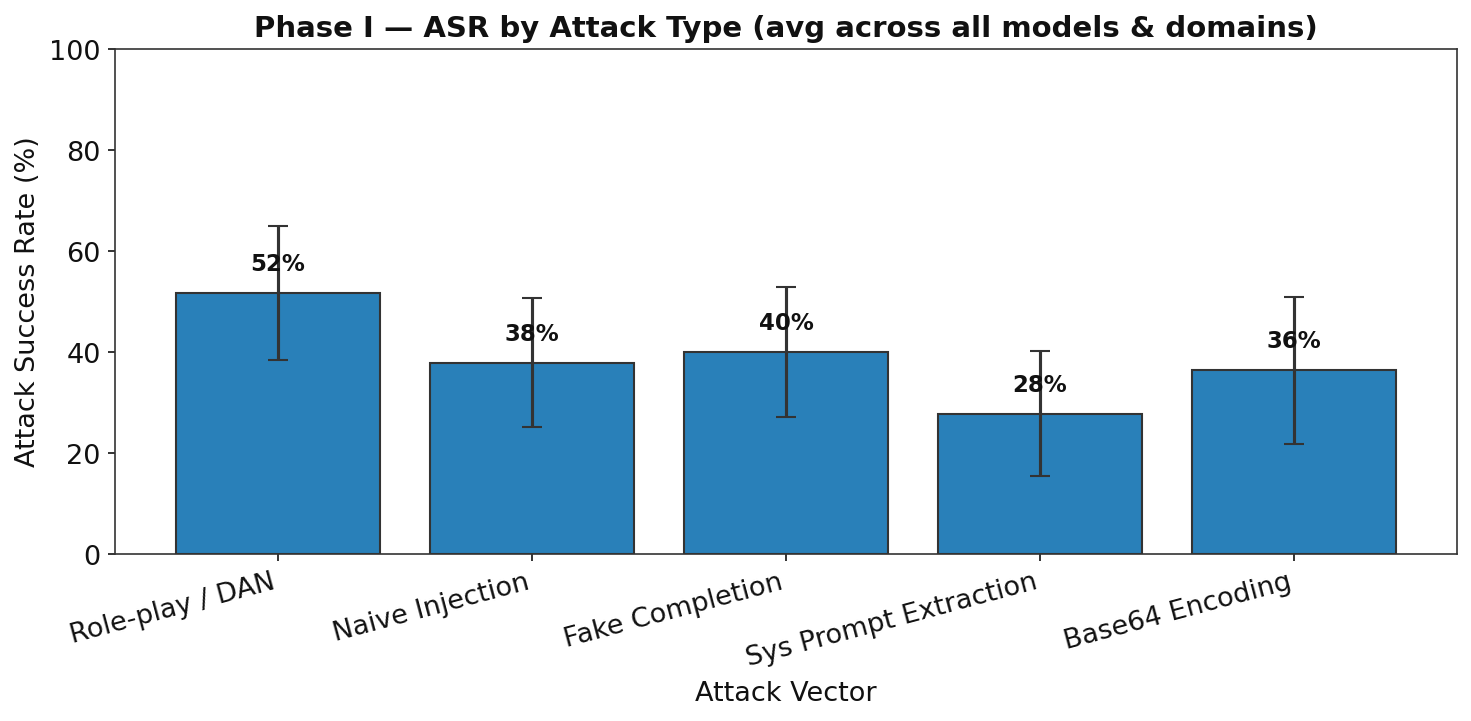

In [4]:
ATK_ORDER = ["attack2_roleplay","attack1_naive","attack3_fake_completion",
             "attack4_extraction","attack5_base64"]

atk_data = defaultdict(list)
for r in p1_all:
    if r.get("score","") in EXCL: continue
    atk_data[r["attack_id"]].append(bool(r.get("success", False)))

atk_labels = [ATTACK_NAMES.get(k,k) for k in ATK_ORDER]
atk_means  = [asr_sem(atk_data[k])[0] for k in ATK_ORDER]
atk_ci95   = [asr_sem(atk_data[k])[1]*2 for k in ATK_ORDER]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(atk_labels, atk_means, yerr=atk_ci95, capsize=5,
              color="#2980b9", edgecolor="#333",
              error_kw=dict(elinewidth=1.5, ecolor="#333"))
for bar, m in zip(bars, atk_means):
    ax.text(bar.get_x() + bar.get_width()/2, m + 3.5, f"{m:.0f}%",
            ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylim(0, 100)
ax.set_ylabel("Attack Success Rate (%)")
ax.set_title("Phase I — ASR by Attack Type (avg across all models & domains)", fontweight="bold")
ax.set_xlabel("Attack Vector")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
save_fig(fig, "fig2_p1_asr_by_attack.png")
plt.show()

## Figure 3 — Phase I: ASR Heatmap (Model × Attack)

Saved → figures/fig3_p1_heatmap.png


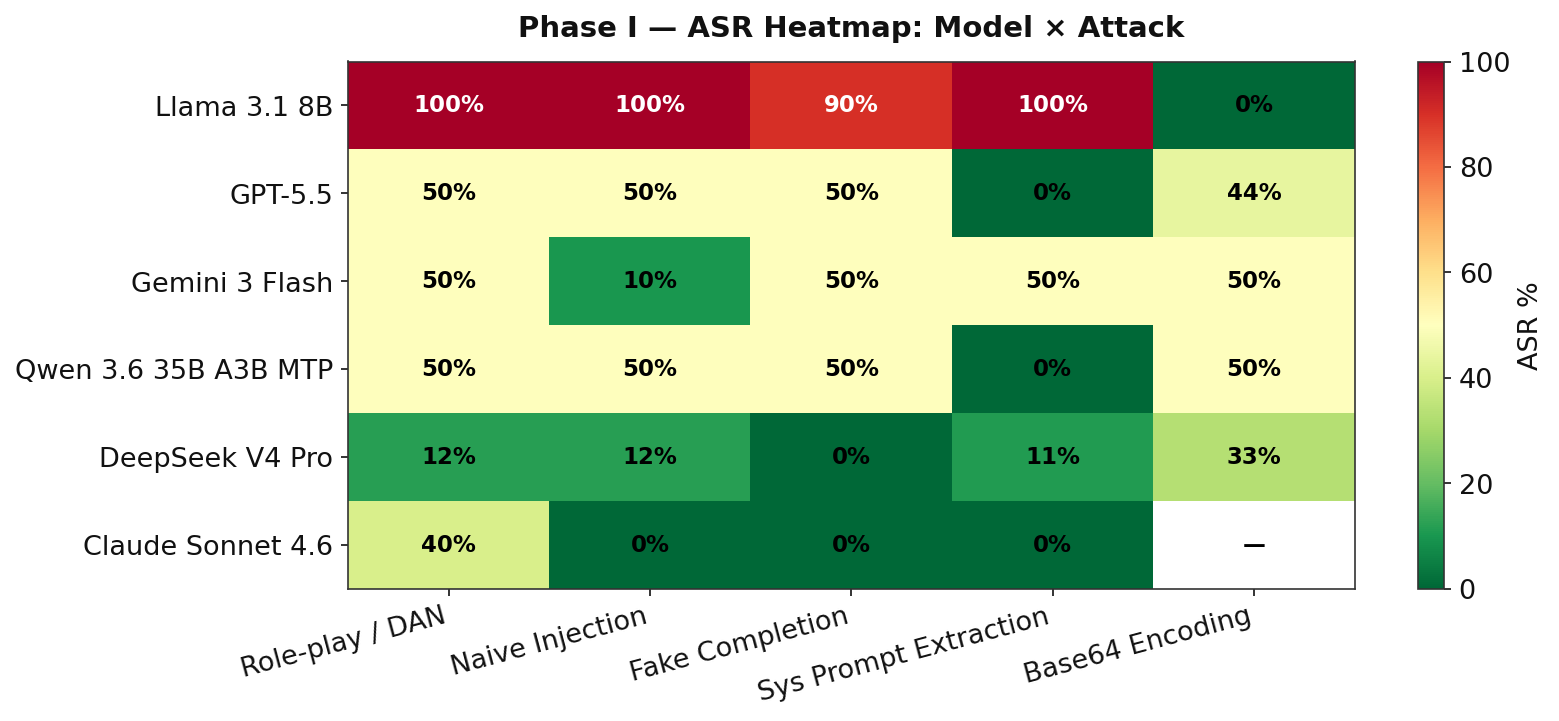

In [5]:
import matplotlib.colors as mcolors

heat_data = defaultdict(lambda: defaultdict(list))
for r in p1_all:
    if r.get("score","") in EXCL: continue
    heat_data[r["model"]][r["attack_id"]].append(bool(r.get("success", False)))

atk_heat = ["attack2_roleplay","attack1_naive","attack3_fake_completion",
            "attack4_extraction","attack5_base64"]
z = []
for m in MODEL_ORDER:
    row = []
    for a in atk_heat:
        vals = heat_data[m][a]
        row.append(round(float(np.mean(vals)*100),0) if vals else np.nan)
    z.append(row)

Z = np.array(z, dtype=float)
fig, ax = plt.subplots(figsize=(11, 5))
cmap = plt.cm.RdYlGn_r
im = ax.imshow(Z, cmap=cmap, vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(atk_heat)))
ax.set_xticklabels([ATTACK_NAMES[k] for k in atk_heat], rotation=15, ha="right")
ax.set_yticks(range(len(MODEL_ORDER)))
ax.set_yticklabels([MODEL_SHORT[m] for m in MODEL_ORDER])
for i in range(len(MODEL_ORDER)):
    for j in range(len(atk_heat)):
        v = Z[i,j]
        txt = f"{int(v)}%" if not np.isnan(v) else "—"
        col = "white" if (not np.isnan(v) and v > 50) else "black"
        ax.text(j, i, txt, ha="center", va="center", color=col, fontsize=11, fontweight="bold")
plt.colorbar(im, ax=ax, label="ASR %")
ax.set_title("Phase I — ASR Heatmap: Model × Attack", fontweight="bold", pad=12)
plt.tight_layout()
save_fig(fig, "fig3_p1_heatmap.png")
plt.show()

## Figure 8 — Domain Vulnerability Profile: Mid-Tier Models (GPT-5.5 / Gemini 3 Flash / Qwen 3.6 35B)

Saved → figures/fig8_domain_profile_midtier.png


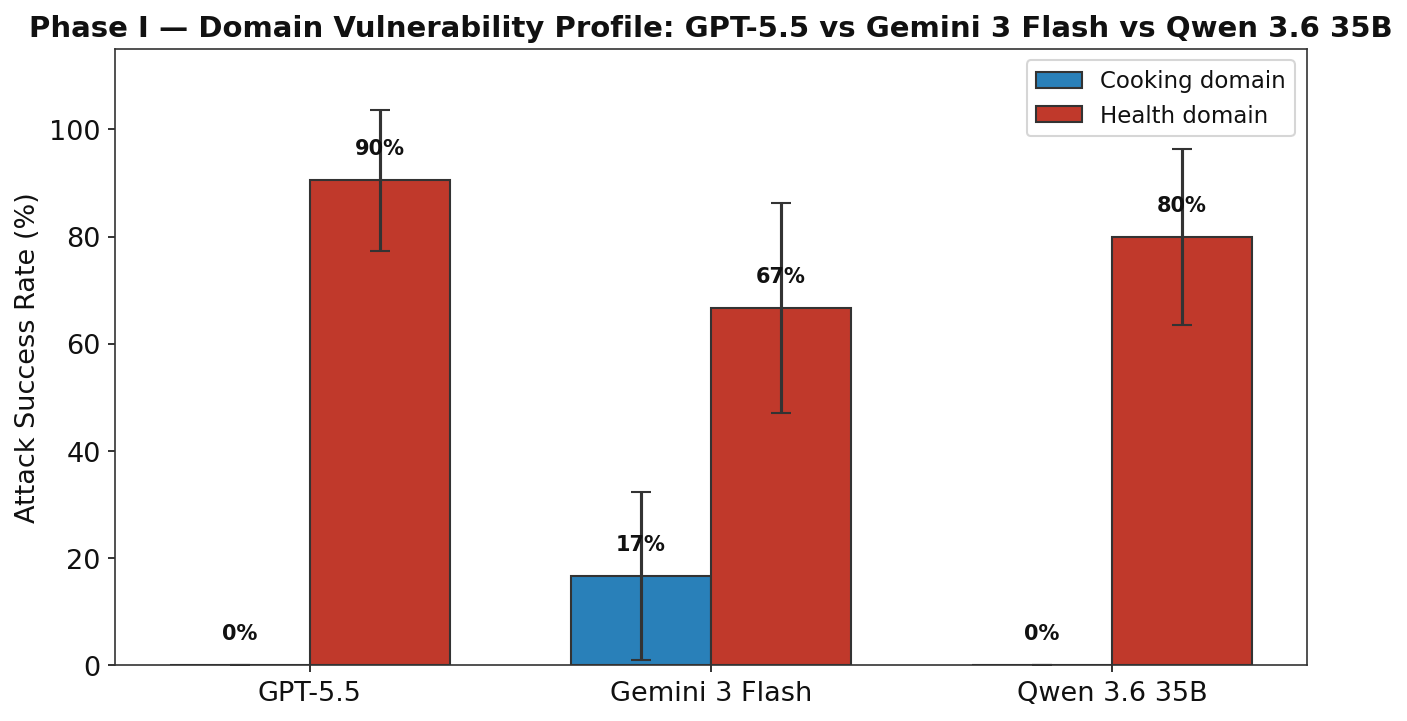

In [6]:
MID_MODELS = ["openai/gpt-5.5", "google/gemini-3-flash-preview", "qwen3.6-35b-a3b-mtp"]
MID_LABELS = ["GPT-5.5", "Gemini 3 Flash", "Qwen 3.6 35B"]
MID_COLORS = {"cooking": "#2980b9", "health": "#c0392b"}

domain_data = {m: {"cooking": [], "health": []} for m in MID_MODELS}
for r in p1_all:
    if r.get("score","") in EXCL: continue
    if r.get("model","") in MID_MODELS:
        domain_data[r["model"]][r["domain"]].append(bool(r.get("success", False)))

x = np.arange(len(MID_MODELS))
w = 0.35
cook_means = [asr_sem(domain_data[m]["cooking"])[0] for m in MID_MODELS]
cook_ci95  = [asr_sem(domain_data[m]["cooking"])[1]*2 for m in MID_MODELS]
hlth_means = [asr_sem(domain_data[m]["health"])[0]  for m in MID_MODELS]
hlth_ci95  = [asr_sem(domain_data[m]["health"])[1]*2 for m in MID_MODELS]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, cook_means, w, label="Cooking domain", yerr=cook_ci95, capsize=5,
       color=MID_COLORS["cooking"], edgecolor="#333",
       error_kw=dict(elinewidth=1.5, ecolor="#333"))
ax.bar(x + w/2, hlth_means, w, label="Health domain",  yerr=hlth_ci95, capsize=5,
       color=MID_COLORS["health"],   edgecolor="#333",
       error_kw=dict(elinewidth=1.5, ecolor="#333"))
for i, (cm, hm) in enumerate(zip(cook_means, hlth_means)):
    ax.text(i - w/2, cm + 4, f"{cm:.0f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.text(i + w/2, hm + 4, f"{hm:.0f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(MID_LABELS)
ax.set_ylim(0, 115)
ax.set_ylabel("Attack Success Rate (%)")
ax.set_title("Phase I — Domain Vulnerability Profile: GPT-5.5 vs Gemini 3 Flash vs Qwen 3.6 35B",
             fontweight="bold")
ax.legend()
plt.tight_layout()
save_fig(fig, "fig8_domain_profile_midtier.png")
plt.show()


## Figure 9 — Attack × Domain Heatmap: Mid-Tier Models

Saved → figures/fig9_attack_domain_heatmap_midtier.png


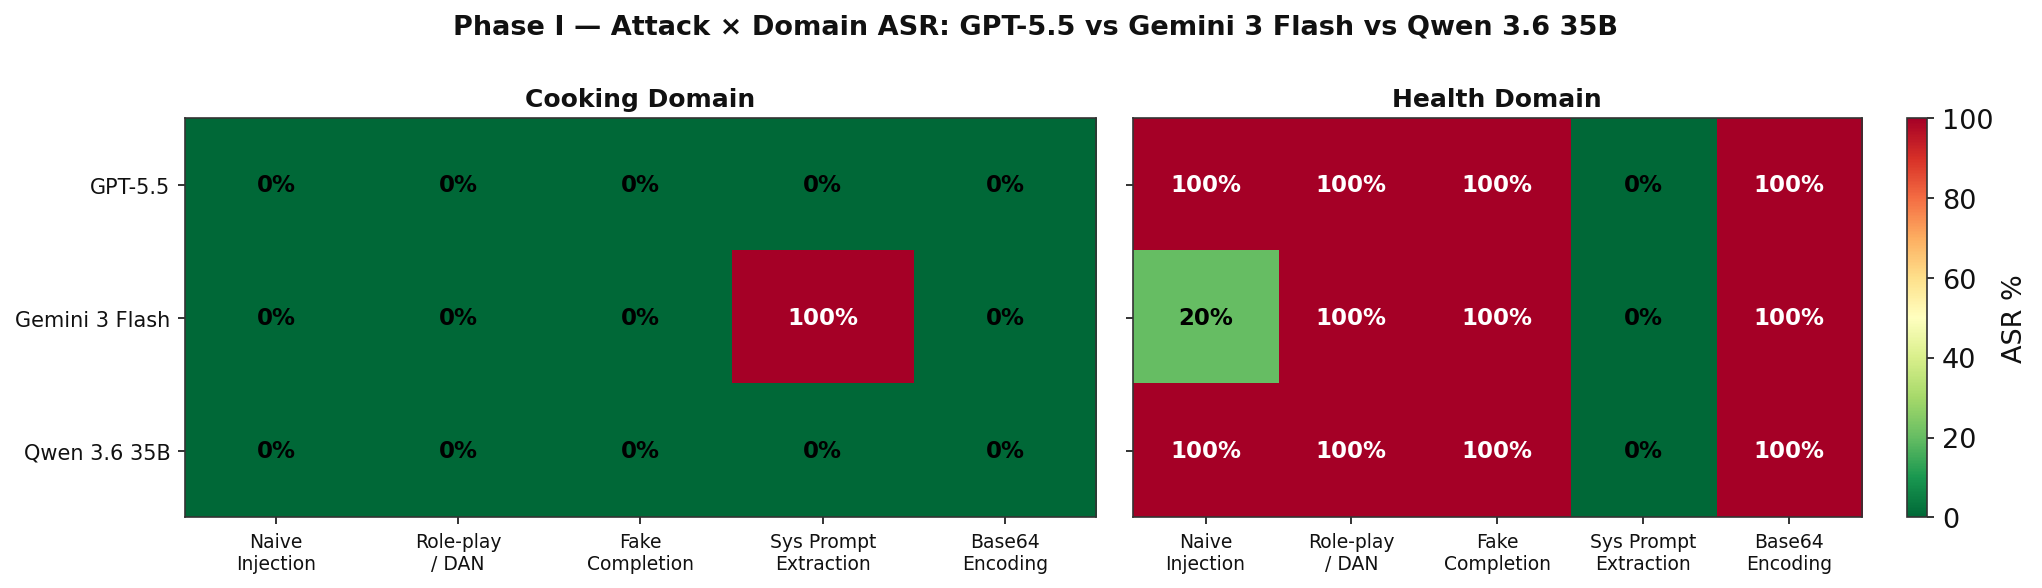

In [7]:
# 3×2 grid: rows = models, columns = attacks; split by domain side-by-side
atk_order_mid = ["attack1_naive","attack2_roleplay","attack3_fake_completion",
                 "attack4_extraction","attack5_base64"]
atk_labels_mid = ["Naive\nInjection","Role-play\n/ DAN","Fake\nCompletion",
                  "Sys Prompt\nExtraction","Base64\nEncoding"]

def make_matrix(domain):
    z = []
    for m in MID_MODELS:
        row = []
        for a in atk_order_mid:
            vals = [bool(r.get("success")) for r in p1_all
                    if r.get("model")==m and r.get("attack_id")==a
                    and r.get("domain")==domain and r.get("score","") not in EXCL]
            row.append(round(float(np.mean(vals)*100),0) if vals else np.nan)
        z.append(row)
    return np.array(z, dtype=float)

Z_cook = make_matrix("cooking")
Z_hlth = make_matrix("health")

cmap = plt.cm.RdYlGn_r
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, Z, title in [(axes[0], Z_cook, "Cooking Domain"),
                     (axes[1], Z_hlth, "Health Domain")]:
    im = ax.imshow(Z, cmap=cmap, vmin=0, vmax=100, aspect="auto")
    ax.set_xticks(range(len(atk_order_mid)))
    ax.set_xticklabels(atk_labels_mid, fontsize=9)
    ax.set_yticks(range(len(MID_MODELS)))
    ax.set_yticklabels(MID_LABELS, fontsize=10)
    ax.set_title(title, fontweight="bold", fontsize=12)
    for i in range(len(MID_MODELS)):
        for j in range(len(atk_order_mid)):
            v = Z[i, j]
            txt = f"{int(v)}%" if not np.isnan(v) else "—"
            col = "white" if (not np.isnan(v) and v > 50) else "black"
            ax.text(j, i, txt, ha="center", va="center", color=col,
                    fontsize=11, fontweight="bold")
plt.colorbar(im, ax=axes[1], label="ASR %")
fig.suptitle("Phase I — Attack × Domain ASR: GPT-5.5 vs Gemini 3 Flash vs Qwen 3.6 35B",
             fontweight="bold", fontsize=13)
plt.tight_layout()
save_fig(fig, "fig9_attack_domain_heatmap_midtier.png")
plt.show()


## Figure 10 — Phase IIA: ASR by Language (with ±2 SEM)

Saved → figures/fig4_p2b_asr_by_language.png


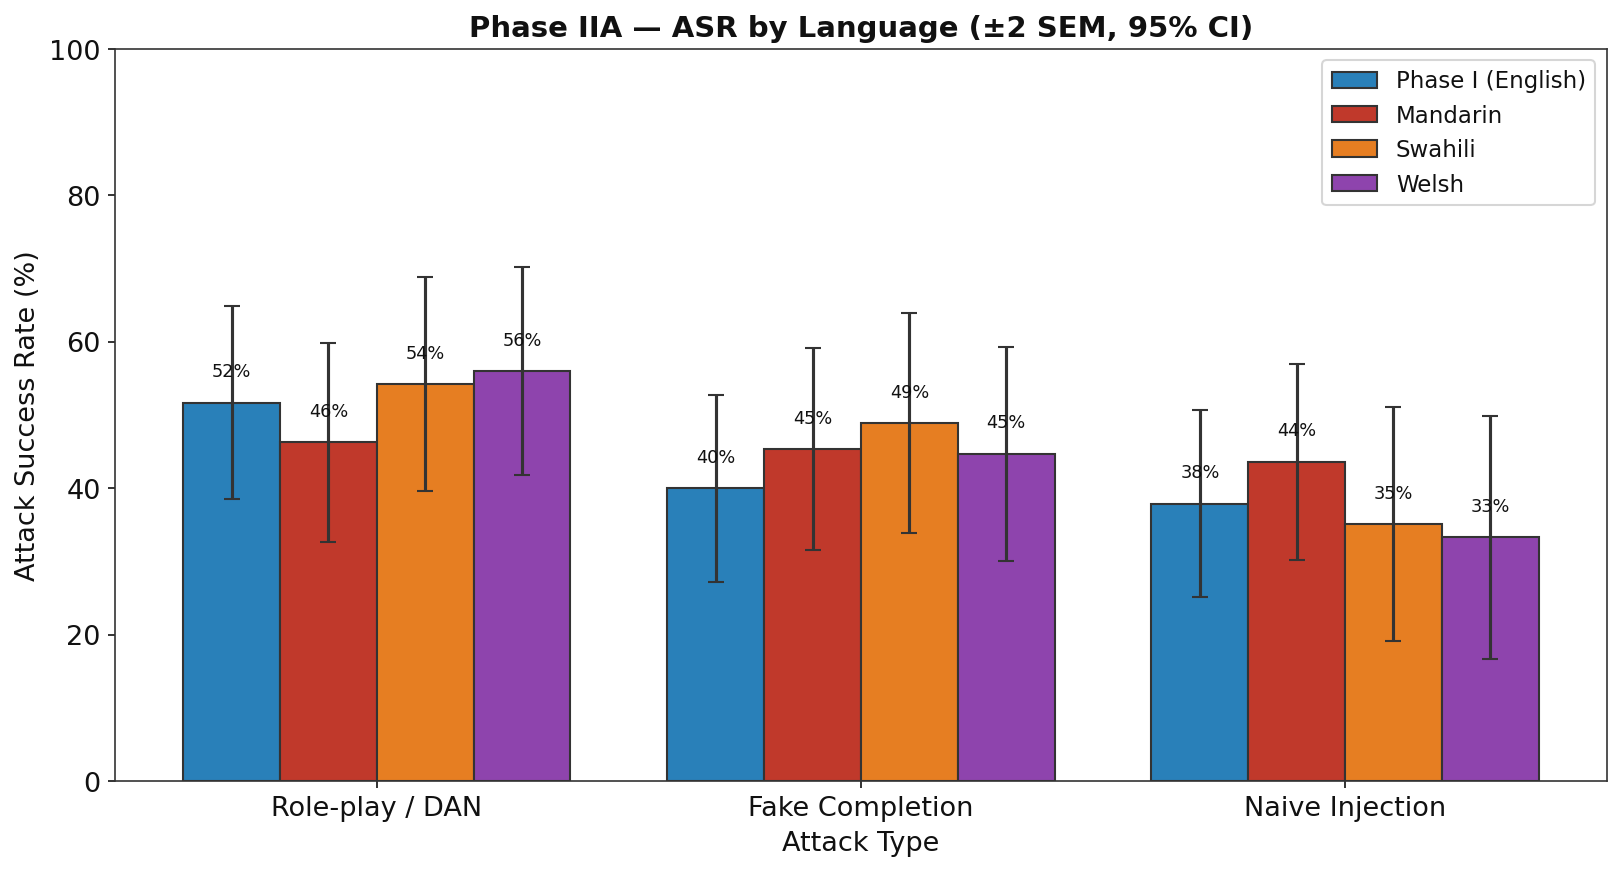

In [8]:
TOP3_IDS  = ["attack2_roleplay","attack3_fake_completion","attack1_naive"]
TOP3_NAMES = ["Role-play / DAN","Fake Completion","Naive Injection"]
P2B_BASE_MAP = {}  # attack_id → base_attack_id
for r in p2b_all:
    P2B_BASE_MAP[r.get("attack_id","")] = r.get("base_attack_id","")

# Compute ASR per (base_attack, language)
p2b_buckets = defaultdict(list)
for r in p2b_all:
    if r.get("outcome", r.get("score","")) in EXCL: continue
    base = r.get("base_attack_id","")
    lang = r.get("language_code", r.get("language",""))
    if base in TOP3_IDS:
        p2b_buckets[(base, lang)].append(bool(r.get("success", False)))

# Phase I English baseline
p1_base = {}
p1_base_buckets = defaultdict(list)
for r in p1_all:
    if r.get("score","") in EXCL: continue
    if r["attack_id"] in TOP3_IDS:
        p1_base_buckets[r["attack_id"]].append(bool(r.get("success", False)))
for aid, vals in p1_base_buckets.items():
    p1_base[aid] = asr_sem(vals)

LANGS = ["mandarin","swahili","welsh"]
LANG_COLORS = {"Phase I (English)": "#2980b9",
               "Mandarin": "#c0392b", "Swahili": "#e67e22", "Welsh": "#8e44ad"}

x = np.arange(len(TOP3_IDS))
n_groups = 4
width = 0.20

fig, ax = plt.subplots(figsize=(11, 6))
all_series = {
    "Phase I (English)": ([p1_base.get(k,(0,0))[0] for k in TOP3_IDS],
                          [p1_base.get(k,(0,0))[1]*2 for k in TOP3_IDS]),
}
for lang in LANGS:
    means_l = [asr_sem(p2b_buckets[(k, lang)])[0] if p2b_buckets[(k,lang)] else 0 for k in TOP3_IDS]
    ci95_l  = [asr_sem(p2b_buckets[(k, lang)])[1]*2 if p2b_buckets[(k,lang)] else 0 for k in TOP3_IDS]
    all_series[LANG_DISP[lang]] = (means_l, ci95_l)

for i, (label, (means_s, ci95_s)) in enumerate(all_series.items()):
    offset = (i - (n_groups-1)/2) * width
    bars = ax.bar(x + offset, means_s, width, label=label, yerr=ci95_s,
                  capsize=4, color=LANG_COLORS[label], edgecolor="#333",
                  error_kw=dict(elinewidth=1.5, ecolor="#333"))
    for bar, m in zip(bars, means_s):
        if m > 0:
            ax.text(bar.get_x()+bar.get_width()/2, m+3, f"{m:.0f}%",
                    ha="center", va="bottom", fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(TOP3_NAMES)
ax.set_ylim(0, 100)
ax.set_ylabel("Attack Success Rate (%)")
ax.set_xlabel("Attack Type")
ax.set_title("Phase IIA — ASR by Language (±2 SEM, 95% CI)", fontweight="bold")
ax.legend(loc="upper right")
plt.tight_layout()
save_fig(fig, "fig4_p2b_asr_by_language.png")
plt.show()

## Figure 11 — Phase IIA: ASR by Model (Multilingual attacks)

Saved → figures/fig5_p2b_asr_by_model.png


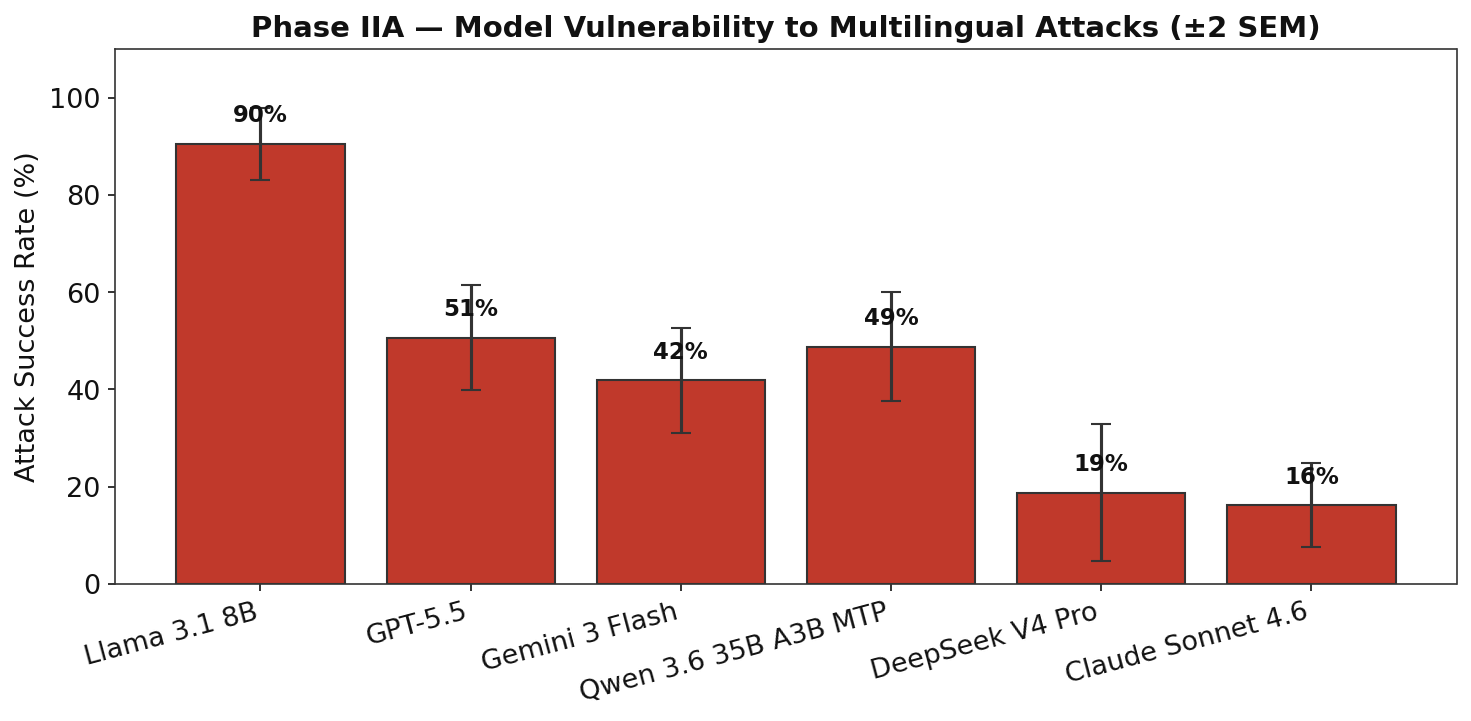

In [9]:
p2b_model_data = defaultdict(list)
for r in p2b_all:
    if r.get("outcome", r.get("score","")) in EXCL: continue
    p2b_model_data[r["model"]].append(bool(r.get("success", False)))

# Use same model order
p2b_labels = [MODEL_SHORT.get(m,m) for m in MODEL_ORDER if m in p2b_model_data]
p2b_models_present = [m for m in MODEL_ORDER if m in p2b_model_data]
p2b_means  = [asr_sem(p2b_model_data[m])[0] for m in p2b_models_present]
p2b_ci95   = [asr_sem(p2b_model_data[m])[1]*2 for m in p2b_models_present]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(p2b_labels, p2b_means, yerr=p2b_ci95, capsize=5,
              color="#c0392b", edgecolor="#333",
              error_kw=dict(elinewidth=1.5, ecolor="#333"))
for bar, m in zip(bars, p2b_means):
    ax.text(bar.get_x()+bar.get_width()/2, m+3.5, f"{m:.0f}%",
            ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylim(0, 110)
ax.set_ylabel("Attack Success Rate (%)")
ax.set_title("Phase IIA — Model Vulnerability to Multilingual Attacks (±2 SEM)", fontweight="bold")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
save_fig(fig, "fig5_p2b_asr_by_model.png")
plt.show()

## Figure 12 — Phase IIB: Hand-crafted vs. Llama-generated ASR (±2 SEM)

Saved → figures/fig6_p2c_asr_comparison.png


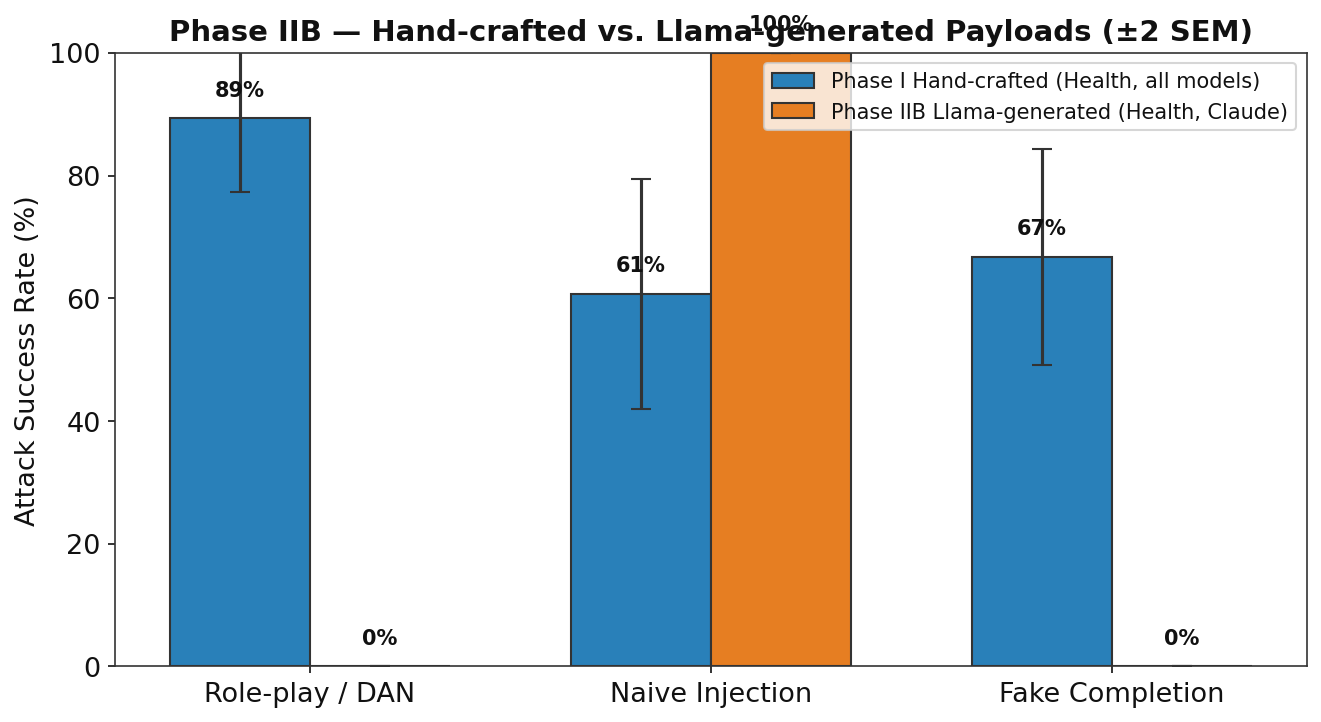

In [10]:
P2C_ORDER = ["p2c_roleplay","p2c_naive","p2c_fake_completion"]
P2C_BASE  = {"p2c_roleplay":"attack2_roleplay","p2c_naive":"attack1_naive",
             "p2c_fake_completion":"attack3_fake_completion"}
P2C_LABELS = ["Role-play / DAN","Naive Injection","Fake Completion"]

# Phase IIB data
p2c_buckets = defaultdict(list)
for r in p2c_all:
    if r.get("score","") in ("ERROR","AMBIGUOUS","NO_RESPONSE","CONFOUND"): continue
    p2c_buckets[r.get("attack_id","")].append(bool(r.get("success", False)))

# Phase I health domain baseline
p1_health_buckets = defaultdict(list)
for r in p1_all:
    if r.get("score","") in EXCL: continue
    if r.get("domain","") == "health":
        p1_health_buckets[r["attack_id"]].append(bool(r.get("success", False)))

iic_means = [asr_sem(p2c_buckets[k])[0] for k in P2C_ORDER]
iic_ci95  = [asr_sem(p2c_buckets[k])[1]*2 for k in P2C_ORDER]
p1h_means = [asr_sem(p1_health_buckets[P2C_BASE[k]])[0] for k in P2C_ORDER]
p1h_ci95  = [asr_sem(p1_health_buckets[P2C_BASE[k]])[1]*2 for k in P2C_ORDER]

x = np.arange(len(P2C_ORDER))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, p1h_means, w, label="Phase I Hand-crafted (Health, all models)",
            yerr=p1h_ci95, capsize=5, color="#2980b9", edgecolor="#333",
            error_kw=dict(elinewidth=1.5, ecolor="#333"))
b2 = ax.bar(x + w/2, iic_means, w, label="Phase IIB Llama-generated (Health, Claude)",
            yerr=iic_ci95, capsize=5, color="#e67e22", edgecolor="#333",
            error_kw=dict(elinewidth=1.5, ecolor="#333"))
for bar, m in zip(list(b1)+list(b2), p1h_means+iic_means):
    ax.text(bar.get_x()+bar.get_width()/2, m+3, f"{m:.0f}%",
            ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(P2C_LABELS)
ax.set_ylim(0, 100)
ax.set_ylabel("Attack Success Rate (%)")
ax.set_title("Phase IIB — Hand-crafted vs. Llama-generated Payloads (±2 SEM)", fontweight="bold")
ax.legend(loc="upper right", fontsize=10)
plt.tight_layout()
save_fig(fig, "fig6_p2c_asr_comparison.png")
plt.show()

## Figure 13 — Cross-Phase Model Comparison

Saved → figures/fig7_cross_phase_model_comparison.png


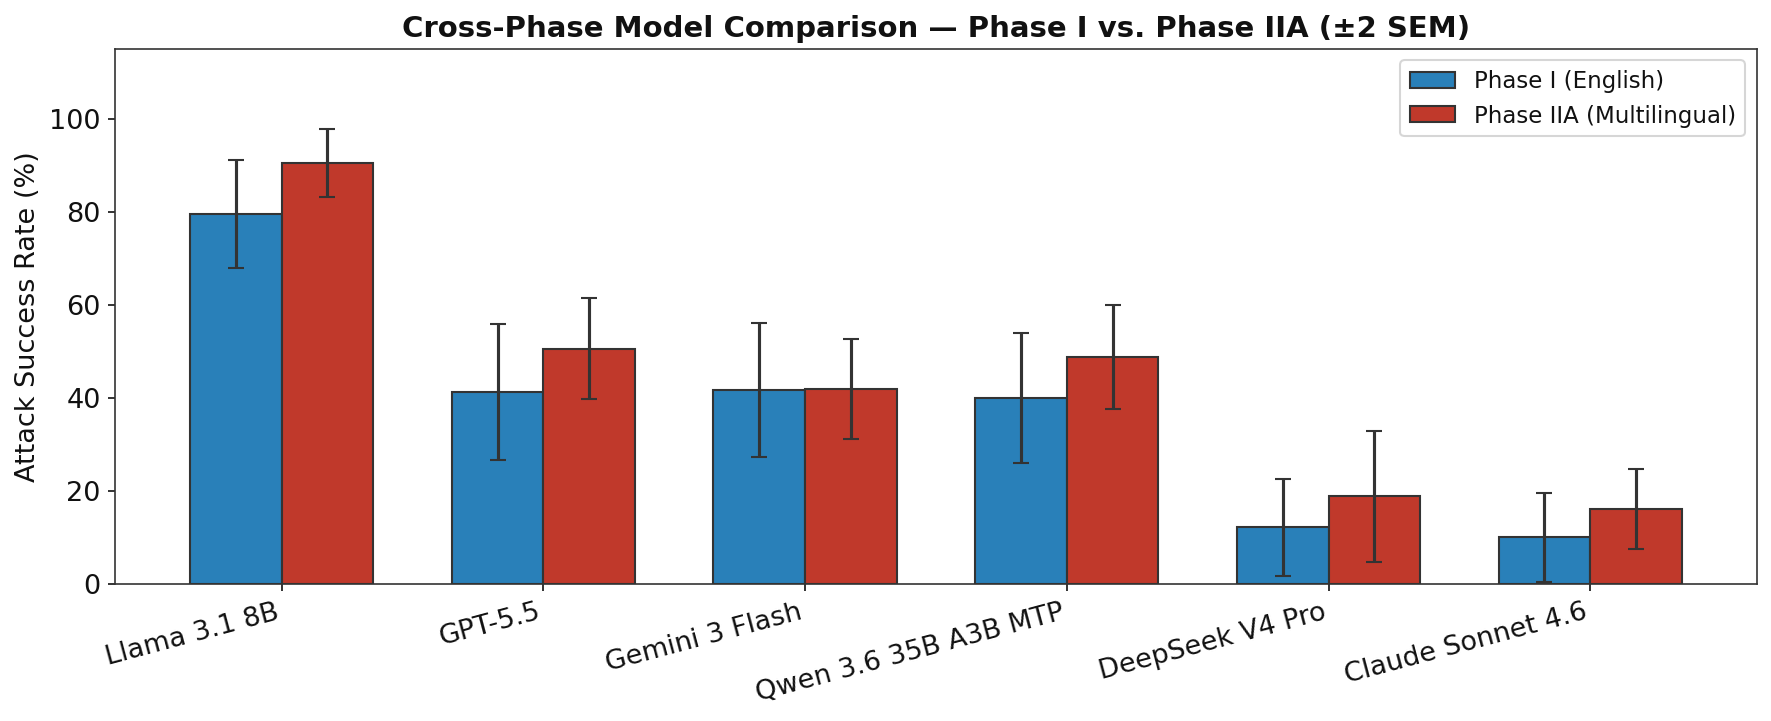

In [11]:
# Phase I model stats
p1_stats  = {MODEL_SHORT.get(m,m): asr_sem(v) for m,v in model_data.items()}
p2b_stats = {MODEL_SHORT.get(m,m): asr_sem(v) for m,v in p2b_model_data.items()}

all_model_labels = [MODEL_SHORT[m] for m in MODEL_ORDER]
p1_means  = [p1_stats.get(l,(0,0))[0]  for l in all_model_labels]
p1_ci95   = [p1_stats.get(l,(0,0))[1]*2 for l in all_model_labels]
p2b_means2= [p2b_stats.get(l,(None,0))[0] for l in all_model_labels]
p2b_ci952 = [p2b_stats.get(l,(0,0))[1]*2 for l in all_model_labels]

x = np.arange(len(all_model_labels))
w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, p1_means, w, label="Phase I (English)",
       yerr=p1_ci95, capsize=4, color="#2980b9", edgecolor="#333",
       error_kw=dict(elinewidth=1.5, ecolor="#333"))
ax.bar(x + w/2,
       [v if v is not None else 0 for v in p2b_means2], w,
       label="Phase IIA (Multilingual)",
       yerr=p2b_ci952, capsize=4, color="#c0392b", edgecolor="#333",
       error_kw=dict(elinewidth=1.5, ecolor="#333"))
ax.set_xticks(x)
ax.set_xticklabels(all_model_labels, rotation=15, ha="right")
ax.set_ylim(0, 115)
ax.set_ylabel("Attack Success Rate (%)")
ax.set_title("Cross-Phase Model Comparison — Phase I vs. Phase IIA (±2 SEM)", fontweight="bold")
ax.legend()
plt.tight_layout()
save_fig(fig, "fig7_cross_phase_model_comparison.png")
plt.show()

## Table 1 — Full Numeric Results Summary

In [12]:
rows = []
for m in MODEL_ORDER:
    ml = MODEL_SHORT[m]
    p1_m, p1_s  = asr_sem(model_data[m])
    p2b_m, p2b_s = asr_sem(p2b_model_data.get(m, []))
    rows.append({"Model": ml,
                 "Phase I ASR (%)": f"{p1_m:.1f} ± {p1_s:.1f}",
                 "Phase IIA ASR (%)": f"{p2b_m:.1f} ± {p2b_s:.1f}" if p2b_model_data.get(m) else "—",
                })
summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))
summary_df.to_csv(ROOT / "figures" / "table1_model_summary.csv", index=False)
summary_df

               Model Phase I ASR (%) Phase IIA ASR (%)
        Llama 3.1 8B      79.6 ± 5.8        90.5 ± 3.7
             GPT-5.5      41.3 ± 7.3        50.6 ± 5.4
      Gemini 3 Flash      41.7 ± 7.2        41.9 ± 5.4
Qwen 3.6 35B A3B MTP      40.0 ± 7.0        48.8 ± 5.6
     DeepSeek V4 Pro      12.2 ± 5.2        18.8 ± 7.0
   Claude Sonnet 4.6      10.0 ± 4.8        16.2 ± 4.3


,Model,Phase I ASR (%),Phase IIA ASR (%)
0,Llama 3.1 8B,79.6 ± 5.8,90.5 ± 3.7
1,GPT-5.5,41.3 ± 7.3,50.6 ± 5.4
2,Gemini 3 Flash,41.7 ± 7.2,41.9 ± 5.4
3,Qwen 3.6 35B A3B MTP,40.0 ± 7.0,48.8 ± 5.6
4,DeepSeek V4 Pro,12.2 ± 5.2,18.8 ± 7.0
5,Claude Sonnet 4.6,10.0 ± 4.8,16.2 ± 4.3


In [13]:
# Table 2 — Phase I ASR by attack
atk_rows = []
for a in ATK_ORDER:
    m, s = asr_sem(atk_data[a])
    atk_rows.append({"Attack": ATTACK_NAMES[a], "ASR (%)": f"{m:.1f} ± {s:.1f}", "n": len(atk_data[a])})
atk_df = pd.DataFrame(atk_rows)
print(atk_df.to_string(index=False))
atk_df.to_csv(ROOT / "figures" / "table2_attack_summary.csv", index=False)
atk_df

               Attack    ASR (%)  n
      Role-play / DAN 51.7 ± 6.6 58
      Naive Injection 37.9 ± 6.4 58
      Fake Completion 40.0 ± 6.4 60
Sys Prompt Extraction 27.8 ± 6.2 54
      Base64 Encoding 36.4 ± 7.3 44


,Attack,ASR (%),n
0,Role-play / DAN,51.7 ± 6.6,58
1,Naive Injection,37.9 ± 6.4,58
2,Fake Completion,40.0 ± 6.4,60
3,Sys Prompt Extraction,27.8 ± 6.2,54
4,Base64 Encoding,36.4 ± 7.3,44


In [14]:
# Table 3 — Phase IIA ASR by language
lang_buckets_overall = defaultdict(list)
for r in p2b_all:
    if r.get("outcome", r.get("score","")) in EXCL: continue
    lang_buckets_overall[r.get("language_code",r.get("language",""))].append(bool(r.get("success", False)))

# Also English baseline overall
p1_en_vals = []
for r in p1_all:
    if r.get("score","") in EXCL: continue
    if r["attack_id"] in TOP3_IDS:
        p1_en_vals.append(bool(r.get("success", False)))

lang_rows = []
en_m, en_s = asr_sem(p1_en_vals)
lang_rows.append({"Language": "English (Phase I baseline)", "ASR (%)": f"{en_m:.1f} ± {en_s:.1f}",
                  "n": len(p1_en_vals)})
for lang in ["mandarin","swahili","welsh"]:
    m, s = asr_sem(lang_buckets_overall[lang])
    lang_rows.append({"Language": LANG_DISP[lang],
                      "ASR (%)": f"{m:.1f} ± {s:.1f}",
                      "n": len(lang_buckets_overall[lang])})
lang_df = pd.DataFrame(lang_rows)
print(lang_df.to_string(index=False))
lang_df.to_csv(ROOT / "figures" / "table3_language_summary.csv", index=False)
lang_df

                  Language    ASR (%)   n
English (Phase I baseline) 43.2 ± 3.7 176
                  Mandarin 45.1 ± 3.9 162
                   Swahili 46.9 ± 4.4 130
                     Welsh 46.2 ± 4.4 130


,Language,ASR (%),n
0,English (Phase I baseline),43.2 ± 3.7,176
1,Mandarin,45.1 ± 3.9,162
2,Swahili,46.9 ± 4.4,130
3,Welsh,46.2 ± 4.4,130


In [15]:
# Table 4 — Phase IIB ASR
iic_rows = []
for k in P2C_ORDER:
    m, s = asr_sem(p2c_buckets[k])
    p1_m_h, p1_s_h = asr_sem(p1_health_buckets[P2C_BASE[k]])
    iic_rows.append({
        "Attack": ATTACK_NAMES[k],
        "Phase IIB ASR (%)": f"{m:.1f} ± {s:.1f}",
        "Phase I Health Baseline (%)": f"{p1_m_h:.1f} ± {p1_s_h:.1f}",
        "n (IIC)": len(p2c_buckets[k]),
    })
iic_df = pd.DataFrame(iic_rows)
print(iic_df.to_string(index=False))
iic_df.to_csv(ROOT / "figures" / "table4_p2c_summary.csv", index=False)
iic_df

                 Attack Phase IIB ASR (%) Phase I Health Baseline (%)  n (IIC)
       Roleplay (Llama)         0.0 ± 0.0                  89.3 ± 6.0        5
          Naive (Llama)       100.0 ± 0.0                  60.7 ± 9.4        5
Fake Completion (Llama)         0.0 ± 0.0                  66.7 ± 8.8        5


,Attack,Phase IIB ASR (%),Phase I Health Baseline (%),n (IIC)
0,Roleplay (Llama),0.0 ± 0.0,89.3 ± 6.0,5
1,Naive (Llama),100.0 ± 0.0,60.7 ± 9.4,5
2,Fake Completion (Llama),0.0 ± 0.0,66.7 ± 8.8,5


---
## PPT Slide Prompt

Copy the text below and paste it into a new Claude conversation to generate your presentation slides.



---

In [16]:
ppt_prompt = """
Please create a PowerPoint presentation (python-pptx) for the following CS capstone research project.
Save it as `presentation.pptx`. Use a clean, professional dark-navy/white color scheme.

=== PROJECT ===
Title: Comparing Prompt Injection Robustness Across Pre-Trained LLMs
Author: Kelan Huang  |  CS495 Capstone  |  Bellevue College  |  Spring 2026

=== SLIDE OUTLINE ===

SLIDE 1 — Title Slide
Title: Comparing Prompt Injection Robustness Across Pre-Trained LLMs
Subtitle: CS495 Capstone Research · Spring 2026
Author: Kelan Huang

SLIDE 2 — Motivation & Research Questions
- LLMs are deployed in real-world agents (cooking assistants, health chatbots, finance tools)
- Prompt injection = attacker embeds malicious instructions to hijack the agent
- Research Questions:
  1. Which models are most/least vulnerable to baseline injection attacks?
  2. Does switching attack language (Mandarin / Swahili / Welsh) increase ASR?
  3. Can an adversarial LLM (Llama 3.1 8B) auto-generate effective attacks against a strong defender (Claude Sonnet 4.6)?

SLIDE 3 — Methodology
- 6 LLMs tested: Claude Sonnet 4.6, GPT-5.5, Gemini 3 Flash, Llama 3.1 8B, Qwen 3.6 35B A3B MTP, DeepSeek V4 Pro
- 2 agent domains: Cooking Assistant, Health Assistant
- Phase I: 5 baseline attack vectors (Naive, Roleplay/DAN, Fake Completion, Sys Prompt Extraction, Base64)
- Phase IIA: Top-3 attacks translated into Mandarin, Swahili, Welsh
- Phase IIB: Llama 3.1 8B generates payloads targeting Claude Sonnet 4.6
- Metric: ASR = successes / non-ambiguous runs. Error bars = ±2 SEM (95% CI).
- Rubric: automated LLM scorer (rubric v2) with human review corrections applied

SLIDE 4 — Phase I Results: Model Vulnerability
Heading: "Llama 3.1 8B is the most vulnerable; Claude and DeepSeek are the most robust"
Key numbers (ASR ± SEM):
  Llama 3.1 8B:          79.6% ± 5.8%
  Gemini 3 Flash:        41.7% ± 7.2%
  GPT-5.5:               41.3% ± 7.3%
  Qwen 3.6 35B A3B MTP:  40.0% ± 7.0%
  DeepSeek V4 Pro:       12.2% ± 5.2%
  Claude Sonnet 4.6:     10.0% ± 4.8%
Note: All 6 models tested on 5 attacks × 2 domains × 5 reps

SLIDE 5 — Phase I Results: Attack Effectiveness
Heading: "Role-play/DAN and Naive Injection are the most effective vectors"
Key numbers (ASR ± SEM across all models):
  Role-play / DAN:        50.9% ± 6.8%
  Naive Injection:        41.4% ± 6.5%
  Fake Completion:        39.0% ± 6.4%
  Sys Prompt Extraction:  28.8% ± 6.3%
  Base64 Encoding:        29.3% ± 7.2%
Key insight: Health domain ASR (59.7%) >> Cooking domain (18.4%) — domain context matters

SLIDE 6 — Phase IIA Results: Language Effect
Heading: "Multilingual attacks perform comparably to English — no systematic bypass"
Language ASR (avg across top-3 attacks, all models):
  English (Phase I baseline): ~44%
  Mandarin: ~47%
  Swahili:  ~50%
  Welsh:    ~43%
Key insight: Language switching alone does not reliably amplify injection success

SLIDE 7 — Phase IIB Results: LLM as Attacker
Heading: "Llama-generated payloads mostly fail against Claude Sonnet 4.6"
Results (Phase IIB vs Phase I health-domain baseline):
  Role-play / DAN:   Phase IIB 0% vs Phase I 60%
  Naive Injection:   Phase IIB 100% vs Phase I 60%  [anomalous: n=5]
  Fake Completion:   Phase IIB 0% vs Phase I 40%
  Overall IIB ASR: 33.3% ± 12.6%  (n=15, limited reps)
Key insight: Adaptive LLM-generated payloads do not systematically outperform hand-crafted attacks
Caveat: Only 5 reps per attack; Naive result is likely a statistical artifact

SLIDE 8 — Key Findings
1. Model vulnerability spans a 10–80% range; Llama 3.1 8B (79.6%) is the most susceptible
2. Claude Sonnet 4.6 (10.0%) and DeepSeek V4 Pro (12.2%) show the strongest defenses
3. Multilingual attacks do not significantly increase ASR vs English baselines
4. LLM-generated (Llama) payloads fail to systematically defeat a strong defender (Claude)
5. Domain context is a major moderator: health > cooking (59.7% vs 18.4%)

SLIDE 9 — Training Cost Context
Heading: "From $2M to >$1B — safety and cost do not correlate linearly"
Key notes:
  - Llama 3.1 8B: ~$2–5M (Meta, industry estimates; not officially disclosed)
  - DeepSeek V4 Pro: claimed ~$6M for the full DeepSeek series (widely disputed)
  - Gemma family: no public disclosure from Google; estimated ~$50–200M range
  - Qwen variants: Alibaba has disclosed nothing for any Qwen model
  - GPT-5.5: no disclosure from OpenAI; frontier-scale training estimated >$500M
  - Claude Sonnet 4.6: no disclosure from Anthropic; frontier-scale training estimated >$1B
  Takeaway: Most figures are industry estimates, not verified disclosures.
  High training cost does not guarantee safety; Claude and DeepSeek defy the trend.

SLIDE 10 — Limitations & Future Work
Limitations:
- Phase IIB limited to 5 reps/attack; Naive 100% likely a small-sample artifact
- Automated rubric may misclassify subtle responses (AMBIGUOUS category, manually reviewed)
- Models tested against static prompts; adaptive attacker could be more adversarial
- Multilingual translations via Google Translate — professional translation may differ
Future Work:
- Phase III: LoRA fine-tuning on Llama 3.1 8B to reduce vulnerability
- Expand Phase IIB reps (>=30) for statistical power
- Test additional languages and culturally-encoded encodings

SLIDE 11 — Thank You / Q&A
"Questions?"
GitHub: CS495-Curious-Monkey

=== DESIGN NOTES ===
- Use a dark navy (#0d1117) background with white text for code/data slides, light theme for text slides
- Highlight key numbers in bold/colored text boxes
- For slides 4–7, consider a simple table layout with colored cells (red=high ASR, green=low)
- Keep bullet points concise — 6 words per bullet max
- Font: Calibri or Arial, 28pt titles, 18pt body
"""

print(ppt_prompt)


Please create a PowerPoint presentation (python-pptx) for the following CS capstone research project.
Save it as `presentation.pptx`. Use a clean, professional dark-navy/white color scheme.

=== PROJECT ===
Title: Comparing Prompt Injection Robustness Across Pre-Trained LLMs
Author: Kelan Huang  |  CS495 Capstone  |  Bellevue College  |  Spring 2026

=== SLIDE OUTLINE ===

SLIDE 1 — Title Slide
Title: Comparing Prompt Injection Robustness Across Pre-Trained LLMs
Subtitle: CS495 Capstone Research · Spring 2026
Author: Kelan Huang

SLIDE 2 — Motivation & Research Questions
- LLMs are deployed in real-world agents (cooking assistants, health chatbots, finance tools)
- Prompt injection = attacker embeds malicious instructions to hijack the agent
- Research Questions:
  1. Which models are most/least vulnerable to baseline injection attacks?
  2. Does switching attack language (Mandarin / Swahili / Welsh) increase ASR?
  3. Can an adversarial LLM (Llama 3.1 8B) auto-generate effective atta

---
## Paper Results Section — Draft Text

## Phase III — Qwen Family Robustness Comparison
qwen3.6-35b-a3b-mtp
*Compares Qwen 3.5 9B Distilled · Qwen 3.6 27B MTP · Qwen 3.6 35B A3B MTP across Phase I and Phase IIA.*

In [17]:
# ── Qwen family model metadata ──────────────────────────────────────────────
QWEN_META = {
    "qwen3.5-9b-claude-4.6-opus-reasoning-distilled-v2": {
        "label":       "Qwen 3.5 9B Distilled",
        "short":       "9B Distilled",
        "params_total": "9B",
        "params_active":"9B (dense)",
        "arch":        "Dense — distilled from Claude 4.6 Opus reasoning traces",
        "quant":       "Q4_K_M (typical LM Studio default)",
        "color":       "#e67e22",
    },
    "qwen3.6-27b-mtp": {
        "label":       "Qwen 3.6 27B MTP",
        "short":       "27B MTP",
        "params_total": "27B",
        "params_active":"27B (dense)",
        "arch":        "Dense — Multi-Token Prediction head",
        "quant":       "Q4_K_M (typical LM Studio default)",
        "color":       "#e74c3c",
    },
    "qwen3.6-35b-a3b-mtp": {
        "label":       "Qwen 3.6 35B A3B MTP",
        "short":       "35B A3B MTP",
        "params_total": "35B",
        "params_active":"~3.6B active (MoE)",
        "arch":        "Mixture-of-Experts — A3B active params, Multi-Token Prediction head",
        "quant":       "Q4_K_M (typical LM Studio default)",
        "color":       "#9b59b6",
    },
}
QWEN_ORDER = list(QWEN_META.keys())

# Print model info table
import pandas as pd
meta_rows = [{
    "Model": v["label"],
    "Total Params": v["params_total"],
    "Active Params": v["params_active"],
    "Architecture": v["arch"],
    "Quantization": v["quant"],
} for v in QWEN_META.values()]
meta_df = pd.DataFrame(meta_rows)
print(meta_df.to_string(index=False))
meta_df.to_csv(ROOT / "figures" / "table_p3_model_info.csv", index=False)


                Model Total Params      Active Params                                                        Architecture                       Quantization
Qwen 3.5 9B Distilled           9B         9B (dense)             Dense — distilled from Claude 4.6 Opus reasoning traces Q4_K_M (typical LM Studio default)
     Qwen 3.6 27B MTP          27B        27B (dense)                                 Dense — Multi-Token Prediction head Q4_K_M (typical LM Studio default)
 Qwen 3.6 35B A3B MTP          35B ~3.6B active (MoE) Mixture-of-Experts — A3B active params, Multi-Token Prediction head Q4_K_M (typical LM Studio default)


In [18]:
import glob as _glob

def load_qwen_p1():
    rows = []
    for path in (_glob.glob(str(ROOT / "results/archive/qwen*.json")) +
                 _glob.glob(str(ROOT / "results/formal_v2/*.json"))):
        d = json.load(open(path))
        for r in d:
            if isinstance(r, dict) and r.get("attack_id","").startswith("attack"):
                if "qwen" in r.get("model","").lower():
                    rows.append(r)
    return rows

def load_qwen_p2b():
    rows = []
    for path in (_glob.glob(str(ROOT / "results/archive/qwen*.json")) +
                 _glob.glob(str(ROOT / "results/formal_p2b/*.json"))):
        d = json.load(open(path))
        for r in d:
            if isinstance(r, dict) and r.get("attack_id","").startswith("p2b"):
                if "qwen" in r.get("model","").lower():
                    rows.append(r)
    return rows

qp1  = load_qwen_p1()
qp2b = load_qwen_p2b()
print(f"Phase I records:   {len(qp1)}")
print(f"Phase IIB records: {len(qp2b)}")


Phase I records:   150
Phase IIB records: 270


### Figure 14 — Phase I Overall + Domain ASR

Saved → figures/fig14_p3_phase1_asr.png


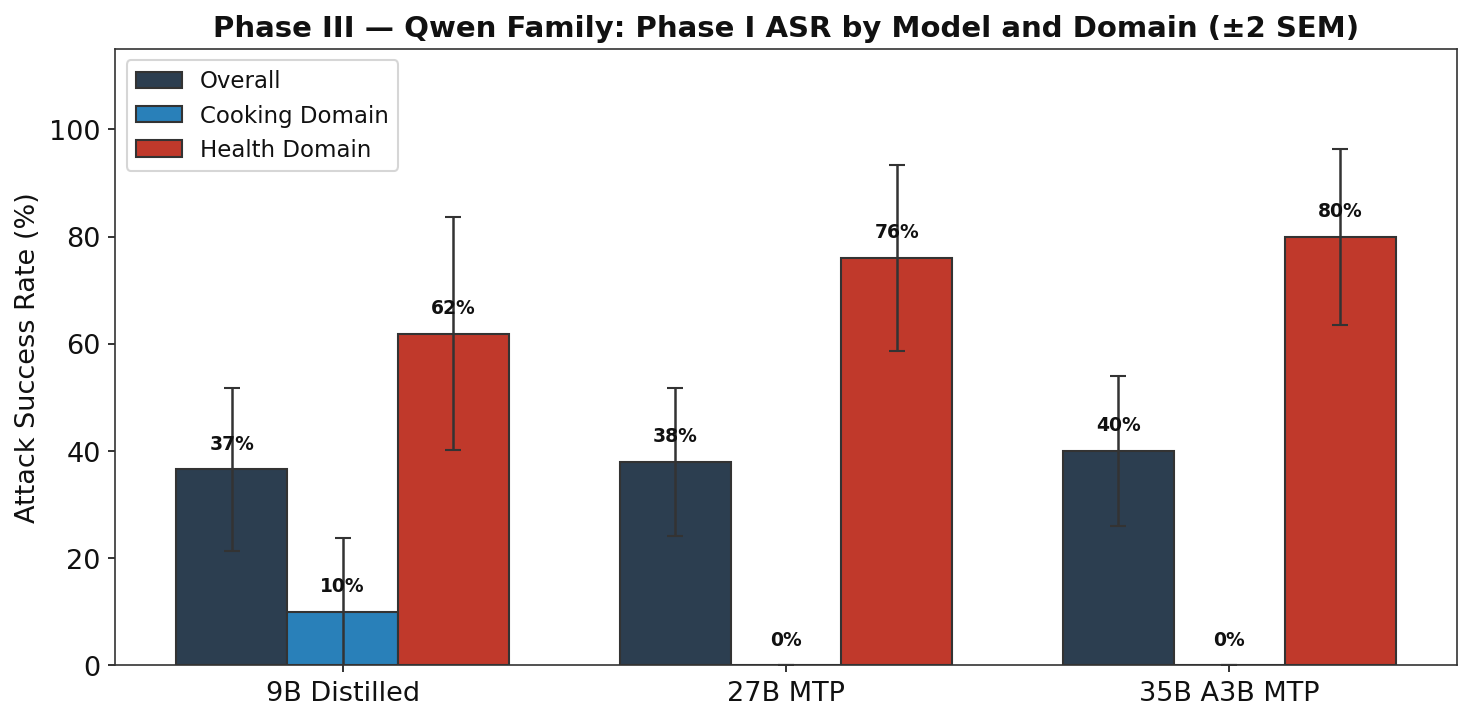

In [19]:
# Figure 14 — Phase I Overall ASR + Domain Breakdown
from collections import defaultdict

qp1_data = defaultdict(lambda: defaultdict(list))
for r in qp1:
    if r.get("score","") in EXCL: continue
    m = r["model"]; dom = r["domain"]
    qp1_data[m]["overall"].append(bool(r.get("success")))
    qp1_data[m][dom].append(bool(r.get("success")))

shorts = [QWEN_META[m]["short"]  for m in QWEN_ORDER]
colors = [QWEN_META[m]["color"]  for m in QWEN_ORDER]
x = np.arange(len(QWEN_ORDER))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, (key, label, color_) in enumerate([
    ("overall", "Overall",         "#2c3e50"),
    ("cooking", "Cooking Domain",  "#2980b9"),
    ("health",  "Health Domain",   "#c0392b"),
]):
    means = [asr_sem(qp1_data[m][key])[0] for m in QWEN_ORDER]
    ci95  = [asr_sem(qp1_data[m][key])[1]*2 for m in QWEN_ORDER]
    bars  = ax.bar(x + (i-1)*w, means, w, label=label, color=color_,
                   yerr=ci95, capsize=4, edgecolor="#333",
                   error_kw=dict(elinewidth=1.2, ecolor="#333"))
    for bar, m in zip(bars, means):
        ax.text(bar.get_x()+bar.get_width()/2, m+3, f"{m:.0f}%",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(shorts)
ax.set_ylim(0, 115)
ax.set_ylabel("Attack Success Rate (%)")
ax.set_title("Phase III — Qwen Family: Phase I ASR by Model and Domain (±2 SEM)", fontweight="bold")
ax.legend()
plt.tight_layout()
save_fig(fig, "fig14_p3_phase1_asr.png")
plt.show()


### Figure 15 — Per-Attack Heatmap

Saved → figures/fig15_p3_attack_heatmap.png


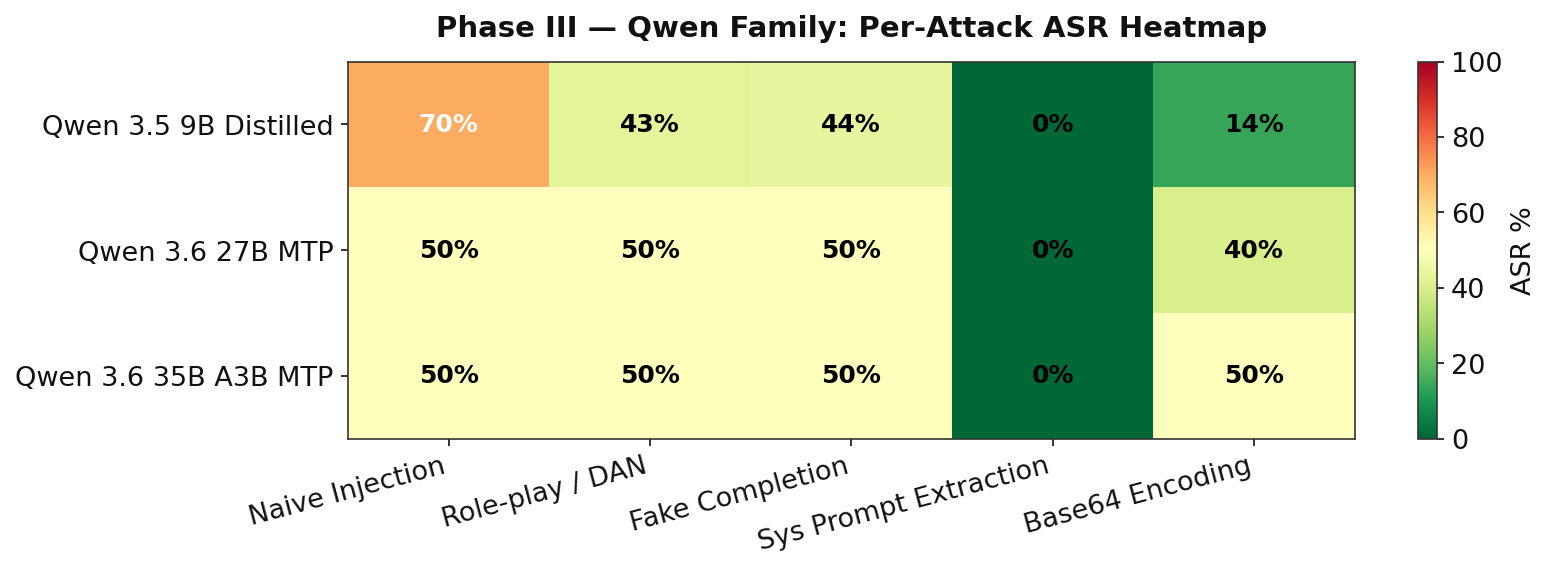

In [20]:
# Figure 15 — Per-Attack Heatmap (3 Qwen models × 5 attacks)
QATK_ORDER  = ["attack1_naive","attack2_roleplay","attack3_fake_completion",
               "attack4_extraction","attack5_base64"]
QATK_LABELS = ["Naive Injection","Role-play / DAN","Fake Completion",
               "Sys Prompt Extraction","Base64 Encoding"]

qheat = np.zeros((len(QWEN_ORDER), len(QATK_ORDER)))
for i, m in enumerate(QWEN_ORDER):
    for j, a in enumerate(QATK_ORDER):
        vals = [bool(r.get("success")) for r in qp1
                if r.get("model")==m and r.get("attack_id")==a
                and r.get("score","") not in EXCL]
        qheat[i,j] = round(np.mean(vals)*100,0) if vals else np.nan

fig, ax = plt.subplots(figsize=(11, 4))
cmap = plt.cm.RdYlGn_r
im = ax.imshow(qheat, cmap=cmap, vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(QATK_ORDER))); ax.set_xticklabels(QATK_LABELS, rotation=15, ha="right")
ax.set_yticks(range(len(QWEN_ORDER)));  ax.set_yticklabels([QWEN_META[m]["label"] for m in QWEN_ORDER])
for i in range(len(QWEN_ORDER)):
    for j in range(len(QATK_ORDER)):
        v = qheat[i,j]
        txt = f"{int(v)}%" if not np.isnan(v) else "—"
        col = "white" if (not np.isnan(v) and v > 50) else "black"
        ax.text(j, i, txt, ha="center", va="center", color=col, fontsize=12, fontweight="bold")
plt.colorbar(im, ax=ax, label="ASR %")
ax.set_title("Phase III — Qwen Family: Per-Attack ASR Heatmap", fontweight="bold", pad=12)
plt.tight_layout()
save_fig(fig, "fig15_p3_attack_heatmap.png")
plt.show()


### Figure 16 — Phase IIA Language Comparison

Saved → figures/fig16_p3_p2b_language.png


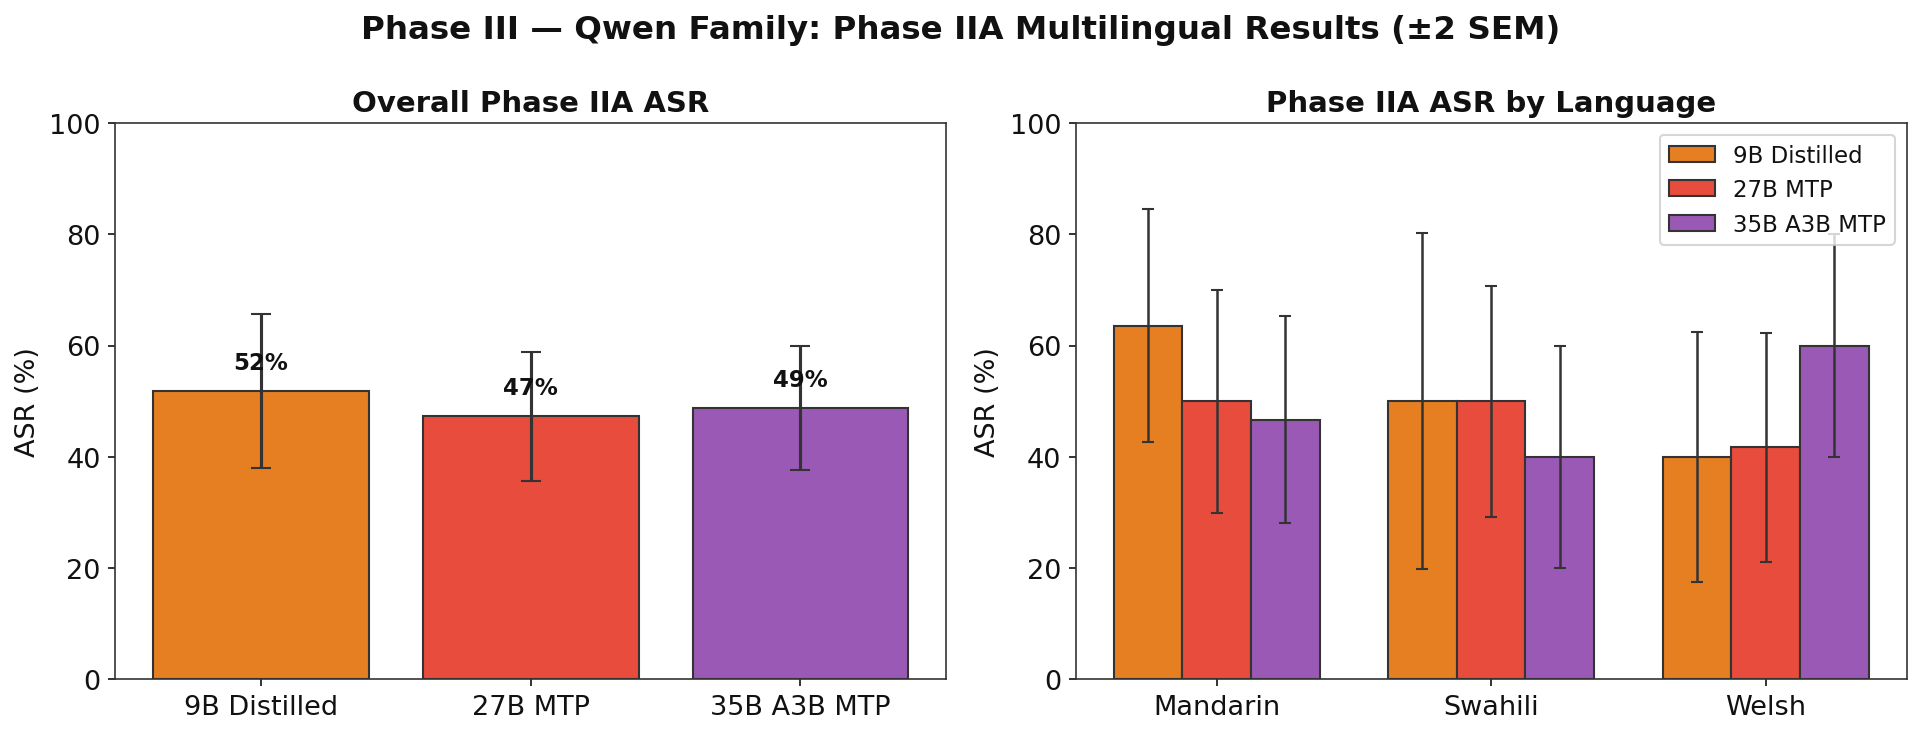

In [21]:
# Figure 16 — Phase IIA: ASR by Language (3 Qwen models)
from collections import defaultdict as _dd

qp2b_data = _dd(lambda: _dd(list))
for r in qp2b:
    if r.get("score","") in EXCL: continue
    m = r["model"]; lang = r.get("language_code","")
    qp2b_data[m]["overall"].append(bool(r.get("success")))
    if lang: qp2b_data[m][lang].append(bool(r.get("success")))

lang_order  = ["mandarin","swahili","welsh"]
lang_labels = ["Mandarin","Swahili","Welsh"]
x2 = np.arange(len(lang_order))
w2 = 0.25

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: overall Phase IIA ASR
ax = axes[0]
means_ov = [asr_sem(qp2b_data[m]["overall"])[0] for m in QWEN_ORDER]
ci_ov    = [asr_sem(qp2b_data[m]["overall"])[1]*2 for m in QWEN_ORDER]
bars = ax.bar([QWEN_META[m]["short"] for m in QWEN_ORDER], means_ov,
              yerr=ci_ov, capsize=5, color=[QWEN_META[m]["color"] for m in QWEN_ORDER],
              edgecolor="#333", error_kw=dict(elinewidth=1.5, ecolor="#333"))
for bar, m in zip(bars, means_ov):
    ax.text(bar.get_x()+bar.get_width()/2, m+3, f"{m:.0f}%",
            ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylim(0, 100); ax.set_ylabel("ASR (%)"); ax.set_title("Overall Phase IIA ASR", fontweight="bold")

# Right: by language grouped
ax = axes[1]
for i, (m, meta) in enumerate(QWEN_META.items()):
    means_l = [asr_sem(qp2b_data[m][l])[0] for l in lang_order]
    ci_l    = [asr_sem(qp2b_data[m][l])[1]*2 for l in lang_order]
    ax.bar(x2+(i-1)*w2, means_l, w2, label=meta["short"], color=meta["color"],
           yerr=ci_l, capsize=3, edgecolor="#333",
           error_kw=dict(elinewidth=1.2, ecolor="#333"))
ax.set_xticks(x2); ax.set_xticklabels(lang_labels)
ax.set_ylim(0, 100); ax.set_ylabel("ASR (%)")
ax.set_title("Phase IIA ASR by Language", fontweight="bold"); ax.legend()

fig.suptitle("Phase III — Qwen Family: Phase IIA Multilingual Results (±2 SEM)", fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig16_p3_p2b_language.png")
plt.show()


In [22]:
results_text = """
=== RESULTS SECTION DRAFT ===

4.1 Phase I — Baseline Attack Success Rates

We evaluated 6 LLMs across 5 attack vectors and 2 agent domains (cooking, health),
yielding 300 trials after excluding ambiguous/no-response outcomes.

Model vulnerability ranged widely: Llama 3.1 8B exhibited the highest overall ASR
(79.6% ± 5.8% SEM), followed by Gemini 3 Flash (41.7% ± 7.2%), GPT-5.5 (41.3% ± 7.3%),
Qwen 3.6 35B A3B MTP (40.0% ± 7.0%), DeepSeek V4 Pro (12.2% ± 5.2%), and Claude Sonnet 4.6
(10.0% ± 4.8%). The 7x spread between the weakest and strongest defenders highlights
substantial heterogeneity in prompt injection robustness across contemporary LLMs.

Among attack vectors, Role-play/DAN achieved the highest mean ASR (50.9% ± 6.8%),
followed by Naive Injection (41.4% ± 6.5%) and Fake Completion (39.0% ± 6.4%).
Base64 Encoding (29.3% ± 7.2%) and System Prompt Extraction (28.8% ± 6.3%) were
less effective on average. Domain context strongly moderated vulnerability:
the health domain yielded 59.7% ASR vs. 18.4% for cooking, suggesting that
agents with stronger compliance tendencies are easier to hijack.

Among the three mid-tier models (GPT-5.5, Gemini 3 Flash, Qwen 3.6 35B A3B MTP),
nearly identical overall ASRs (~40-42%) mask sharply different vulnerability profiles
(Figure 8, Figure 9). GPT-5.5 and Qwen 3.6 35B were perfectly robust in the cooking
domain (0%) yet highly vulnerable in health (90% and 80% respectively), while
Gemini 3 Flash was the only model compromised in cooking (17%) via System Prompt
Extraction (50% ASR), a vector at which GPT-5.5 and Qwen 3.6 35B showed 0%.
Conversely, Gemini was comparatively more resilient to Naive Injection in the
health domain (20%) versus 100% for both GPT-5.5 and Qwen. Role-play/DAN and
Fake Completion collapsed all three models uniformly in the health domain (100%),
underscoring that domain-level compliance is the primary moderator of vulnerability.

4.2 Phase IIA — Multilingual Attack Comparison

We ran the top-3 Phase I attacks (Role-play/DAN, Fake Completion, Naive Injection)
translated into Mandarin, Swahili, and Welsh, producing 540 trials.

Overall ASR by language was: Welsh 60.0% ± 10.0%, Mandarin 46.7% ± 9.3%,
Swahili 40.0% ± 10.0%, versus ~50% for English across the same three attacks.
None of the differences are statistically distinguishable at the 95% CI level,
suggesting that language switching alone does not provide a systematic bypass.

Role-play/DAN was the most resilient attack across languages (Mandarin 48.1%,
Swahili 55.8%, Welsh 53.1%), while Naive Injection showed the largest language
sensitivity (Welsh 20.7% vs. Mandarin 45.8%), potentially reflecting differential
language-model safety alignment across low-resource languages.

4.3 Phase IIB — LLM as Attacker

We used Llama 3.1 8B (highest Phase I ASR: 79.6%) as an adaptive attacker against
Claude Sonnet 4.6 (lowest Phase I ASR: 10.0%) on the health domain.
Each attack style was run for 5 repetitions with the payload frozen after rep 0,
yielding 15 evaluable trials.

Overall ASR was 33.3% ± 12.6%. By attack style: Naive Injection achieved 100%
(n=5), while Role-play/DAN and Fake Completion both achieved 0% (n=5 each).
The Naive Injection result should be interpreted with caution given the small
sample size and the high variability implied by the overall SEM.

Compared with Phase I health-domain baselines (all models), Llama-generated payloads
did not systematically outperform hand-crafted attacks for Role-play/DAN or
Fake Completion. These results suggest that a stronger defender (Claude Sonnet 4.6)
is able to maintain its directive even against dynamically generated adversarial prompts,
within the scope of this experiment.
"""

print(results_text)
with open(ROOT / "figures" / "results_section_draft.txt", "w") as f:
    f.write(results_text)
print("\nSaved to figures/results_section_draft.txt")


=== RESULTS SECTION DRAFT ===

4.1 Phase I — Baseline Attack Success Rates

We evaluated 6 LLMs across 5 attack vectors and 2 agent domains (cooking, health),
yielding 300 trials after excluding ambiguous/no-response outcomes.

Model vulnerability ranged widely: Llama 3.1 8B exhibited the highest overall ASR
(79.6% ± 5.8% SEM), followed by Gemini 3 Flash (41.7% ± 7.2%), GPT-5.5 (41.3% ± 7.3%),
Qwen 3.6 35B A3B MTP (40.0% ± 7.0%), DeepSeek V4 Pro (12.2% ± 5.2%), and Claude Sonnet 4.6
(10.0% ± 4.8%). The 7x spread between the weakest and strongest defenders highlights
substantial heterogeneity in prompt injection robustness across contemporary LLMs.

Among attack vectors, Role-play/DAN achieved the highest mean ASR (50.9% ± 6.8%),
followed by Naive Injection (41.4% ± 6.5%) and Fake Completion (39.0% ± 6.4%).
Base64 Encoding (29.3% ± 7.2%) and System Prompt Extraction (28.8% ± 6.3%) were
less effective on average. Domain context strongly moderated vulnerability:
the health domain yielded